In [1084]:
import sys
import os
import src.analyze as analyze 
import src.stats_utils as stats_utils
import src.mixtures as mixtures
import src.better_optimiation as bopt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import src.EM as EM
from src.EM import compute_estimate, compute_estimate_stable, compute_p_at_ks, compute_estimates_better_mixture
import src.better_em as BEM
import heapq
import src.bem_geometric as bemg
from src.bem_geometric import compute_estimates_better_three_param_geometric, compute_estimates_three_param

Set model and number of samples

In [1085]:
model_name = 'Pythia 1B'#['Claude 3.5 Opus', 'Claude 3.5 Sonnet', 'GPT4o', 'GPT4o Mini', 'Gemini 1.5 Flash', 'Gemini 1.5 Pro', 'Llama 3 8B IT']
samples = 50
#define the ks that we will try to predict
ks = np.array(np.logspace(np.log10(1), np.log10(10000), num=100))

Load all data for monkeys power laws

In [1086]:
#get data for the number of math problems solved
data = analyze.create_or_load_large_language_monkeys_pythia_math_pass_at_k_df()

#this tells us whether each attempt was a success or failure -- I don't think it adds any 
#value given that the attempts were independent
individual_data = analyze.create_or_load_large_language_monkeys_pythia_math_individual_outcomes_df()

Loaded /Users/jkazdan/Documents/Research/monkeys/KoyejoLab-Origin-Power-Laws-Scaling-Inference-Compute/data/processed_data/large_language_monkeys_pythia_math_pass_at_k.parquet with shape:  (90496, 7)
Loaded /Users/jkazdan/Documents/Research/monkeys/KoyejoLab-Origin-Power-Laws-Scaling-Inference-Compute/data/processed_data/large_language_monkeys_pythia_math_individual_outcomes.parquet with shape:  (8960000, 5)


Number of total samples is missing-- fill this in

In [1087]:
#label the number of total samples and compute the number of correct attempts for each problem
data['Num. Samples Total'] = data['Scaling Parameter'].max()
data['Num. Samples Correct'] = data['Score']*data['Num. Samples Total']
data = data[data['Scaling Parameter'] == 1]

Choose which model to analyze

In [1088]:
pythia12_math = data[(data['Model'] == model_name)]

Collect a subset of the data that we use as the training set for prediction

In [1089]:
model_ind_full = individual_data[(individual_data['Model'] == model_name)]
# If you want to shuffle within each Problem Idx group
def shuffle_group(group):
    group = group.copy()
    group['Score'] = np.random.permutation(group['Score'])
    return group

model_ind_full = model_ind_full.groupby('Problem Idx').apply(shuffle_group).reset_index(drop=True)
model_ind = model_ind_full[model_ind_full['Attempt Idx'] <= samples]
model_ind['Num. Samples Correct'] = model_ind.groupby('Problem Idx')['Score'].transform('sum')
model_ind['Num. Samples Total'] = samples
smaller_pythia12_math = model_ind

/var/folders/sc/fyw6v7ks5mnfw0twp1p1k4mr0000gn/T/ipykernel_89062/3660908005.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  model_ind_full = model_ind_full.groupby('Problem Idx').apply(shuffle_group).reset_index(drop=True)
/var/folders/sc/fyw6v7ks5mnfw0twp1p1k4mr0000gn/T/ipykernel_89062/3660908005.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_ind['Num. Samples Correct'] = model_ind.groupby('Problem Idx')['Score'].transform('sum')
/var/folde

In [1090]:
smaller_pythia12_math = smaller_pythia12_math.groupby('Problem Idx').first()

In [1091]:
smaller_pythia12_math.head()

,Attempt Idx,Score,Benchmark,Model,Num. Samples Correct,Num. Samples Total
Problem Idx,,,,,,
82,1,0.0,MATH,Pythia 1B,0.0,50
142,1,0.0,MATH,Pythia 1B,0.0,50
188,1,0.0,MATH,Pythia 1B,0.0,50
201,1,0.0,MATH,Pythia 1B,0.0,50
240,1,0.0,MATH,Pythia 1B,1.0,50


Fit all methods that don't involve mixtures

In [1092]:
# smaller_beta_2_params = analyze.fit_beta_binomial_two_parameters_to_num_samples_and_num_successes(smaller_pythia12_math)
# smaller_beta_2_params_stable = bopt.fit_beta_binomial_two_parameters_stable(smaller_pythia12_math)
#smaller_beta_3_params = analyze.fit_beta_binomial_three_parameters_to_num_samples_and_num_successes(smaller_pythia12_math)
# smaller_beta_3_params_stable = bopt.fit_beta_binomial_three_parameters_stable(smaller_pythia12_math)
smaller_beta_3_discretized_params = analyze.fit_discretized_beta_three_parameters_to_num_samples_and_num_successes(smaller_pythia12_math)

In [1093]:
# smaller_beta_3_params_stable

Compute the original OpenAI method

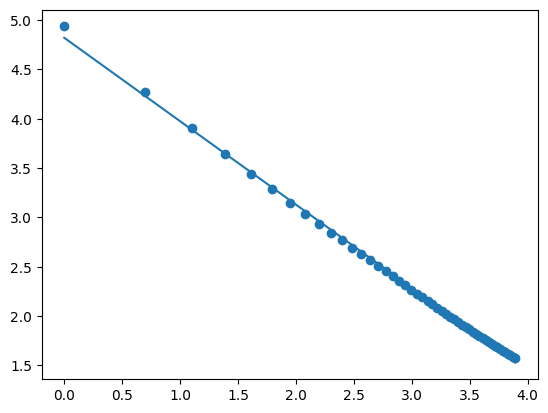

In [1094]:
#original estimator
ks_fit = np.array([i for i in range(1, samples)])
pass_at_ks = analyze.compute_pass_at_k_from_num_samples_and_num_successes_df(smaller_pythia12_math, ks_fit)
pass_at_ks = pass_at_ks.groupby('Scaling Parameter')['Score'].mean()
model = LinearRegression(fit_intercept=True)
model.fit(np.log(ks_fit).reshape(-1,1), -np.log(pass_at_ks))
plt.scatter(np.log(ks_fit), -np.log(pass_at_ks))
plt.plot(np.log(ks_fit), model.predict(np.log(ks_fit).reshape(-1,1)))

Compute beta-binomial mixture parameters

In [1095]:
# n_distr = 1
# beta_mixture = BEM.beta_binom_mixture(n_distr=n_distr, num_successes= smaller_pythia12_math['Num. Samples Correct'], num_trials=smaller_pythia12_math['Num. Samples Total'])
# beta_mixture_params = beta_mixture.fit_mixture()
#beta_mixture_params = EM.fit_beta_binomial_mixture_em(smaller_pythia12_math['Num. Samples Total'], smaller_pythia12_math['Num. Samples Correct'], n_distr)

Sample efficiently by always sampling the question with the lowest success probability so far

In [1096]:
individual_data_model = model_ind_full

heap = []
heapq.heapify(heap)
budget = samples*len(pythia12_math)
results = []
for ele in individual_data_model['Problem Idx'].unique():
    heapq.heappush(heap, (0, ele))
total_samples = 0
while total_samples < budget:
    total_samples += 1
    attempts, index = heapq.heappop(heap)
    attempt_index = attempts + 1
    
    # Check if this attempt exists
    filtered_data = individual_data_model[
        (individual_data_model['Problem Idx'] == index) & 
        (individual_data_model['Attempt Idx'] == attempt_index)
    ]
    
    if filtered_data.empty:
        continue  # Skip if no data for this attempt
        
    score = filtered_data['Score'].iloc[0]
    attempts += 1
    
    if score == 0:
        heapq.heappush(heap, (attempts, index))  # Fixed: use 'index' not 'ele'
    else:
        results.append({'Problem Idx': index, 'Num. Samples Total': attempts, 'Num. Samples Correct': 1})
while heap:
    attempts, index = heapq.heappop(heap)
    results.append({'Problem Idx': index, 'Num. Samples Total': attempts, 'Num. Samples Correct': 0})
efficient_data = pd.DataFrame(results)

In [1097]:
budget

6400

In [1098]:
individual_data_model[individual_data_model['Problem Idx'] == 131]

,Problem Idx,Attempt Idx,Score,Benchmark,Model


In [1124]:
#version with thompson sampling
individual_data_model = model_ind_full

heap = []
heapq.heapify(heap)
budget = samples*len(pythia12_math)
results = []
starting_distr = [] #(1, 1, 0, index) for index in individual_data_model['Problem Idx'].unique()]

total_samples = 0
for problem in individual_data_model['Problem Idx'].unique():

    #get first sample from every problem so that we can still estimate
    filtered_data = individual_data_model[
        (individual_data_model['Problem Idx'] == problem) & 
        (individual_data_model['Attempt Idx'] == 1)
    ]
    score = filtered_data['Score'].iloc[0]
    #alpha, beta, attempts
    starting_distr.append((1+score, 2-score, 1, problem))
    total_samples += 1    


while total_samples < budget:
    draws = []
    for i, ele in enumerate(starting_distr):
        draws.append(np.random.beta(ele[0], ele[1]))
    draws = np.array(draws)
    med = np.median(draws)
    print(draws)
    print(med)
    m = np.argmax(draws == med)
    print(m)

    alpha, beta, attempts, index = starting_distr[m]

    
    #choose the one with the minimum sample value
        
    attempts += 1
    # Check if this attempt exists
    filtered_data = individual_data_model[
        (individual_data_model['Problem Idx'] == index) & 
        (individual_data_model['Attempt Idx'] == attempts)
    ]

    
    if filtered_data.empty:
        print(f'problem index: {index}')
        print(f'attempt index: {attempts}')
        continue  # Skip if no data for this attempt
    else:
        total_samples +=1
            
        score = filtered_data['Score'].iloc[0]

        
        starting_distr[m] = (alpha + score, beta+ (1-score), attempts, index)
for ele in starting_distr:
    results.append({'Problem Idx': ele[-1], 'Num. Samples Total': ele[-2], 'Num. Samples Correct': ele[0]-1})
efficient_data = pd.DataFrame(results)


0.29576981233035726
0
0.29686908400237955
0
0.2697912001458078
0
0.28788799096078543
0
0.2851779101101365
0
0.3103961908533972
0
0.26542638307110944
0
0.31656269614952487
0
0.2476300699915997
0
0.2564974937319907
0
0.3738560057314916
0
0.272398060145698
0
0.2951566720143543
0
0.30165762393071754
0
0.3253316196866193
0
0.2520191467597276
0
0.33459279697415156
0
0.298181403489721
0
0.3227902305903806
0
0.30912068961992967
0
0.2939827222417717
0
0.32684880105086256
0
0.3236780347367505
0
0.30836509832322356
0
0.3011082631324367
0
0.27527133672805215
0
0.25326025854019946
0
0.341913442724555
0
0.30500718773598895
0
0.2753478636233775
0
0.2872815804015326
0
0.3084523390070293
0
0.3536778541771078
0
0.3002807669820694
0
0.29509462444118895
0
0.2807056345202341
0
0.28645557910581465
0
0.23267694524125476
0
0.27867825260428514
0
0.3610681128652605
0
0.26397230599278476
0
0.31540466114834254
0
0.26346064370810557
0
0.266401410420816
0
0.3095071185205199
0
0.3061582198011146
0
0.2768736702518471

In [1119]:
print(efficient_data)

     Problem Idx  Num. Samples Total  Num. Samples Correct
0             82                6273                  27.0
1            142                   1                   0.0
2            188                   1                   0.0
3            201                   1                   0.0
4            240                   1                   0.0
..           ...                 ...                   ...
123         4861                   1                   0.0
124         4895                   1                   0.0
125         4907                   1                   0.0
126         4975                   1                   0.0
127         4988                   1                   0.0

[128 rows x 3 columns]


In [1120]:
smaller_pythia12_math['Num. Samples Correct'].sum()

46.0

(array([127.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([1.00000e+00, 6.37200e+01, 1.26440e+02, 1.89160e+02, 2.51880e+02,
        3.14600e+02, 3.77320e+02, 4.40040e+02, 5.02760e+02, 5.65480e+02,
        6.28200e+02, 6.90920e+02, 7.53640e+02, 8.16360e+02, 8.79080e+02,
        9.41800e+02, 1.00452e+03, 1.06724e+03, 1.12996e+03, 1.19268e+03,
        1.25540e+03, 1.318

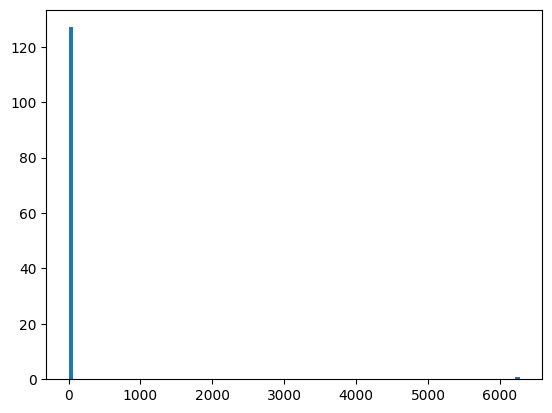

In [1122]:
plt.hist(efficient_data['Num. Samples Total'], bins=100)

Fit geometric mixture

In [1103]:
#beta 2 geometric
n_distr = 1
geom_mix = bemg.beta_geometric_mixture(n_distr=n_distr, num_successes = efficient_data['Num. Samples Correct'], num_trials = efficient_data['Num. Samples Total'])
# geom_params = geom_mix.fit_mixture()
geom_params = analyze.fit_beta_binomial_two_parameters_to_num_samples_and_num_successes(efficient_data)
geom_preds = [compute_estimate(geom_params, k) for k in ks]
beta_std_params = analyze.fit_beta_binomial_two_parameters_to_num_samples_and_num_successes(smaller_pythia12_math)
beta_std_preds = [compute_estimate(beta_std_params, k) for k in ks]
#beta 3 geometric
# smaller_beta_3_params_geometric_stable = bopt.fit_beta_binomial_three_parameters_stable(efficient_data)


Compute p@k estimates

In [1104]:
pass_at_ks = compute_p_at_ks(pythia12_math, ks)

Compute estimates for all methods

In [1105]:
#openai regression predictions
X = ks.reshape(-1,1)
regression_predictions = np.exp(-model.predict(np.log(X)))
#beta discretized estimates
beta_estimates = [compute_estimate(smaller_beta_3_discretized_params, k) for k in ks] 
#2-param binomial mixture
# mixture_estimates = [compute_estimates_better_mixture(smaller_pythia12_math, beta_mixture_params, k, n_distr) for k in ks]
#3-param binomial 
# beta_3_stable_estimates_better = [compute_estimates_three_param(smaller_pythia12_math, smaller_beta_3_params_stable, k) for k in ks] 
#3-param geometric
# three_param_geom_estimates = [bemg.compute_estimates_better_three_param_geometric(efficient_data, smaller_beta_3_params_geometric_stable, k) for k in ks]
#2-param geometric
# geom_correct_estimates = [bemg.compute_estimates_better_mixture_geometric(efficient_data, geom_params, k, n_distr) for k in ks]

Make a graph of the fits

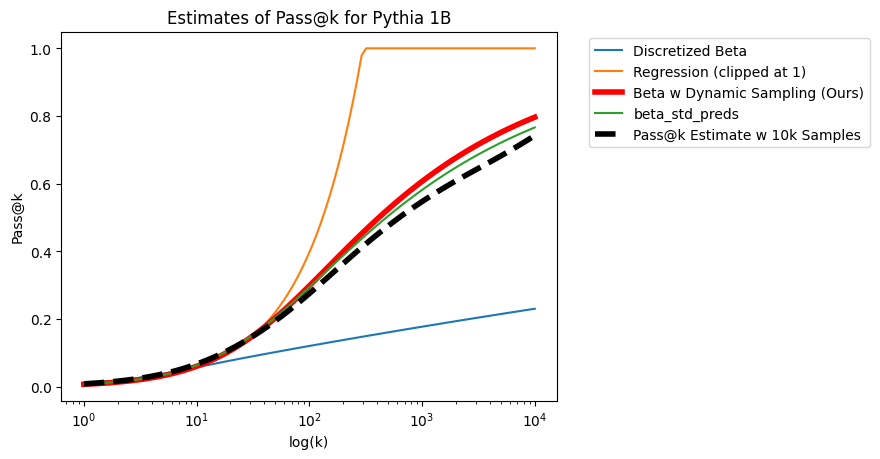

In [1106]:

plt.plot(ks, beta_estimates, label = 'Discretized Beta')
# plt.plot(ks, mixture_estimates, label = 'Beta-Binomial')
plt.plot(ks, np.clip(regression_predictions, 0, 1), label = "Regression (clipped at 1)")
plt.plot(ks, np.clip(geom_preds, 0, 1), label = "Beta w Dynamic Sampling (Ours)", linewidth=4, color='red', linestyle='-', markeredgecolor='darkred')
plt.plot(ks, beta_std_preds, label = 'beta_std_preds')
# plt.plot(ks, beta_3_stable_estimates_better, label = 'Scaled Beta-Binomial')
# plt.plot(ks, three_param_geom_estimates, label = 'Scaled Beta w Dynamic Sampling')
plt.plot(ks, pass_at_ks, label = 'Pass@k Estimate w 10k Samples', linewidth=4, color='black', linestyle='dashed')
plt.title(f'Estimates of Pass@k for {model_name}')
plt.ylabel('Pass@k')
plt.xlabel('log(k)')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

(array([102.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         26.]),
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.

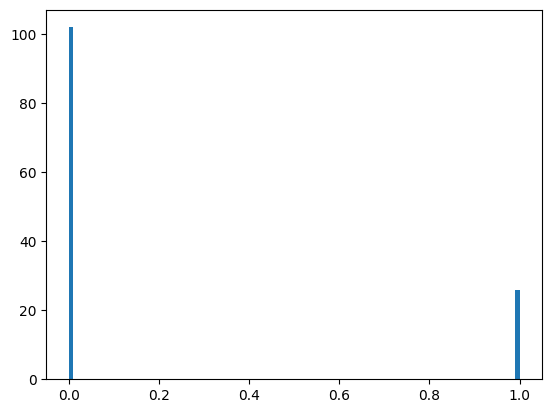

In [1107]:
plt.hist(efficient_data['Num. Samples Correct'], bins = 100)

In [1108]:
efficient_data['Num. Samples Correct'].sum()

26.0

In [1109]:
smaller_pythia12_math['Num. Samples Correct'].sum()

46.0

In [1110]:
def compute_error(pass_at_ks, estimates):
    return np.mean((pass_at_ks - estimates)**2)
    

In [1111]:
compute_error(beta_estimates, pass_at_ks)

0.0702611600487223

In [1112]:
compute_error(regression_predictions, pass_at_ks)

22.91201718394807

In [1113]:
individual_data.groupby(by = 'Problem Idx')['Score'].sum()

Problem Idx
82       548.0
142      243.0
188      412.0
201       10.0
240     8491.0
         ...  
4861     554.0
4895       0.0
4907       0.0
4975       1.0
4988       0.0
Name: Score, Length: 128, dtype: float32

In [1114]:
shuffled_data[shuffled_data['Problem Idx'] == 4]

NameError: name 'shuffled_data' is not defined

In [ ]:
individual_data[individual_data['Problem Idx'] == 4]

,Problem Idx,Attempt Idx,Score,Benchmark,Model


In [ ]:
data = pd.read_csv('notebooks/statistical_analysis/data/processed_data/jailbreaking_shuffled.csv')

In [ ]:
len(data)

4806

In [ ]:
smaller_beta_3_discretized_params

alpha                 0.013109
beta                  0.336569
loc                        0.0
scale                      0.3
neg_log_likelihood    0.151565
success                Success
dtype: object

In [ ]:
geom_params


alpha                  0.301948
beta                  25.522451
loc                    0.000000
scale                  1.000000
neg_log_likelihood     0.364781
aic                    4.729561
bic                   10.433622
Power Law Exponent     0.301948
dtype: float64

In [ ]:
def convert_geom_params(geom_params):
    ret = pd.Series({
        'alpha': geom_params['alpha_0'],
        'beta': geom_params['beta_0'],
        'loc': 0.0,
        'scale': 0
    })
    return ret

In [ ]:
convert_geom_params(geom_params)

KeyError: 'alpha_0'

In [ ]:
pd.read_csv('notebooks/statistical_analysis/data/processed_data/jailbreaking_shuffled_llama.csv')

,method,model,per_problem_budget,trial,1,2,3,4,5,6,...,2811,3237,3727,4291,4941,5689,6551,7543,8685,10000
0,discretized,Llama 3 8B IT,5,0,0.030458,0.047429,0.057775,0.064682,0.069684,0.073550,...,0.179333,0.181571,0.183801,0.186024,0.188242,0.190454,0.192661,0.194861,0.197055,0.199242
1,our_method,Llama 3 8B IT,5,0,0.092243,0.140461,0.160377,0.176101,0.185535,0.201839,...,0.929734,0.934212,0.938402,0.942325,0.946003,0.949445,0.952671,0.955690,0.958517,0.961164
2,regression,Llama 3 8B IT,5,0,0.051040,0.090902,0.127409,0.161896,0.194954,0.226915,...,37.994868,42.732022,48.053795,54.036512,60.770745,68.339604,76.858602,86.433724,97.199713,109.307624
3,pass@k,Llama 3 8B IT,5,0,0.051040,0.090902,0.127409,0.161896,0.194954,0.226915,...,37.994868,42.732022,48.053795,54.036512,60.770745,68.339604,76.858602,86.433724,97.199713,109.307624
4,discretized,Llama 3 8B IT,10,0,0.049425,0.079323,0.098953,0.112858,0.123362,0.131711,...,0.358560,0.362965,0.367336,0.371675,0.375989,0.380270,0.384526,0.388750,0.392944,0.397110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,pass@k,Llama 3 8B IT,85,0,0.044210,0.070426,0.092474,0.112188,0.130330,0.147310,...,9.167323,10.078775,11.079729,12.179761,13.390193,14.720115,16.183392,17.791161,19.558330,21.501178
68,discretized,Llama 3 8B IT,90,0,0.029643,0.056804,0.081753,0.104727,0.125934,0.145557,...,0.829226,0.836063,0.842620,0.848915,0.854963,0.860767,0.866343,0.871693,0.876829,0.881760
69,our_method,Llama 3 8B IT,90,0,0.123068,0.220658,0.299140,0.360637,0.409395,0.451783,...,0.990169,0.991519,0.992682,0.993687,0.994555,0.995304,0.995950,0.996508,0.996988,0.997403
70,regression,Llama 3 8B IT,90,0,0.041145,0.065846,0.086694,0.105376,0.122598,0.138739,...,8.993718,9.897176,10.890282,11.982710,13.185900,14.509104,15.966353,17.568999,19.332186,21.272471
